Saving front.jpg to front (1).jpg
Saving left.jpg to left (1).jpg
Saving right.jpg to right (1).jpg

0: 160x640 4 persons, 2 cars, 1 bus, 61.1ms
Speed: 2.1ms preprocess, 61.1ms inference, 1.0ms postprocess per image at shape (1, 3, 160, 640)


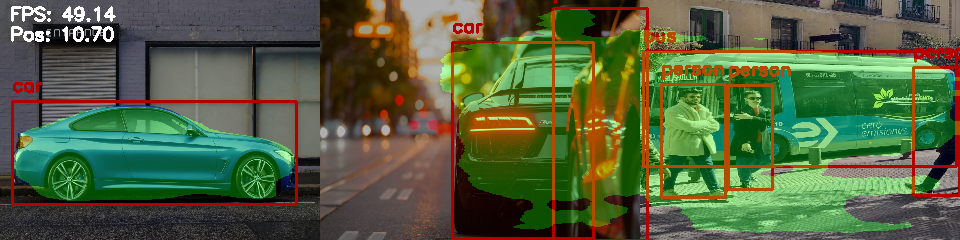

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# COMP6011_20908692
# python code for the integrated system
# Install YOLO
!pip install ultralytics
# Install required libraries
!pip install torch torchvision matplotlib pillow

# upload images(front.jpg, left.jpg,right.jpg are provided to upload in the image folder in appendix)
from google.colab import files
files.upload()

from ultralytics import YOLO
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

# Load the selected models
yolo = YOLO("yolov8n.pt")
deeplab = deeplabv3_resnet50(weights="DEFAULT")
deeplab.eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520,520)),
    T.ToTensor(),
])

# Load multi-camera images
front = cv2.imread("front.jpg")
left = cv2.imread("left.jpg")
right = cv2.imread("right.jpg")

front = cv2.resize(front,(320,240))
left = cv2.resize(left,(320,240))
right = cv2.resize(right,(320,240))

multi = cv2.hconcat([left, front, right])
orig = multi.copy()

# YOLO
results = yolo(multi)[0]
for box in results.boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0])
    label = yolo.names[int(box.cls[0])]
    cv2.rectangle(multi,(x1,y1),(x2,y2),(0,0,255),2)
    cv2.putText(multi,label,(x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

# DeepLab
tensor = transform(orig).unsqueeze(0)
with torch.no_grad():
    output = deeplab(tensor)["out"][0]

mask = output.argmax(0).byte().cpu().numpy()
mask = cv2.resize(mask,(orig.shape[1],orig.shape[0]))

colored = np.zeros_like(orig)
colored[mask > 0] = [0,255,0]

# Fusion
fused = cv2.addWeighted(multi,0.7,colored,0.3,0)

# GNSS + IMU (simple fusion)
gnss = 10 + np.random.normal(0,0.5)
imu = 10 + np.random.normal(0,1)
position = (gnss + imu)/2

# FPS
start = time.time()
time.sleep(0.02)
fps = 1/(time.time()-start)

cv2.putText(fused,f"FPS: {fps:.2f}",(10,20),
            cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)

cv2.putText(fused,f"Pos: {position:.2f}",(10,40),
            cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2)

cv2_imshow(fused)
cv2.imwrite("final_output.jpg", fused)
files.download("final_output.jpg")
cv2.waitKey(0)
cv2.destroyAllWindows()